In [7]:
library(nlme)

ratpup           <- read.table('rat_pup.dat', header=TRUE)
ratpup$sex       <- as.factor(ratpup$sex)
ratpup$litter    <- as.factor(ratpup$litter)
ratpup$treatment <- as.factor(ratpup$treatment)

# Implementing the Model in `R`

...

## Collapsing to Mixed-effects Form
... So, at present, our two-level model is

$$
\begin{alignat*}{1}
    \text{Level 1:} \\
    y^{(k)}_{ij}     &= \mu^{(k)} + \alpha^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2:} \\
    \mu^{(k)}        &= \mu + \gamma_{l} + \xi^{(k)}  \\
    \alpha^{(k)}_{j} &= \alpha_{j} + (\alpha\gamma)_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$

which we can perhaps make a bit clearer by labelling the terms explicitly

$$
\begin{alignat*}{1}
    \text{Level 1:} \\
    \text{weight}^{(k)}_{ij}     &= \text{mean}^{(k)} + \text{sex}^{(k)}_{j} + \eta^{(k)}_{ij}  \\
    \quad \\
    \text{Level 2:} \\
    \text{mean}^{(k)}    &= \text{mean} + \text{treatment}_{l} + \xi^{(k)}  \\
    \text{sex}^{(k)}_{j} &= \text{sex}_{j} + (\text{sex} \times \text{treatment})_{jl} + \phi^{(k)}_{j}
\end{alignat*}
$$

Remember, any term with superscript $(k)$ is defined *specifically* in relation to litter $k$ any term *without* superscript $(k)$ is defined in terms of the *population* as a whole.
...

$$
y^{(k)}_{ij} = \mu + \alpha_{j} + \gamma_{l} + (\alpha\gamma)_{jl} + \xi^{(k)} + \phi^{(k)}_{j} + \eta^{(k)}_{ij}
$$

...

$$
y_{ijk} = \mu + \alpha_{j} + \gamma_{l} + (\alpha\gamma)_{jl} + \xi_{k} + \phi_{jk} + \eta_{ijk}
$$

Where we end up with what is essentially a two-way ANOVA model with *three* error terms.

We can now collapse these levels together to give the mixed-effects specification.

## Implementation Using `lme()`

In [8]:
library(nlme)

lme.ratpup.1 <- lme(fixed  = weight ~ treatment + sex + sex:treatment, # fixed-effects (mean function)
                    random =        ~ 1 + sex|litter,                  # random-effects (variance function)
                    data   = ratpup)                                   # data (long-format)

summary(lme.ratpup.1)

Linear mixed-effects model fit by REML
  Data: ratpup 
      AIC      BIC    logLik
  438.799 476.3564 -209.3995

Random effects:
 Formula: ~1 + sex | litter
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev    Corr  
(Intercept) 0.5019186 (Intr)
sexMale     0.1554335 0.888 
Residual    0.4005464       

Fixed effects:  weight ~ treatment + sex + sex:treatment 
                          Value Std.Error  DF  t-value p-value
(Intercept)            6.200295 0.1685193 292 36.79278  0.0000
treatmentHigh         -0.293458 0.2647520  24 -1.10843  0.2787
treatmentLow          -0.315255 0.2376438  24 -1.32658  0.1971
sexMale                0.441064 0.0878297 292  5.02181  0.0000
treatmentHigh:sexMale -0.083920 0.1529263 292 -0.54876  0.5836
treatmentLow:sexMale  -0.077938 0.1272381 292 -0.61253  0.5407
 Correlation: 
                      (Intr) trtmnH trtmnL sexMal trtH:M
treatmentHigh         -0.637                            
treatmentLow          -0.709 

In [9]:
random.effects(lme.ratpup.1)

    (Intercept)      sexMale
1   0.283091048  0.066250415
2  -0.153500107 -0.033344540
3   0.701543759  0.178278121
4  -0.135362756 -0.031915416
5   0.340037227  0.105202850
6   0.390393255  0.169711123
7  -0.158110148 -0.063206359
8  -0.440380383 -0.124903334
9  -0.935772451 -0.277784567
10  0.108060557  0.011711707
11 -0.319291431 -0.089044095
12  1.080803194  0.297293631
13 -0.268172395 -0.079082057
14 -0.234212253 -0.069014833
15 -0.004590989 -0.009742578
16  0.030052979 -0.004193467
17 -0.521318592 -0.150524666
18  0.183390270  0.088278074
19  0.110812589  0.022647114
20 -0.057473372 -0.006617124
21 -0.749232516 -0.202209691
22 -0.566187590 -0.160408742
23  0.942642618  0.266500217
24 -0.131482487 -0.035557072
25  0.345791183  0.093074636
26  0.273784479  0.073033835
27 -0.115315687 -0.034433183

## Visualising the Model

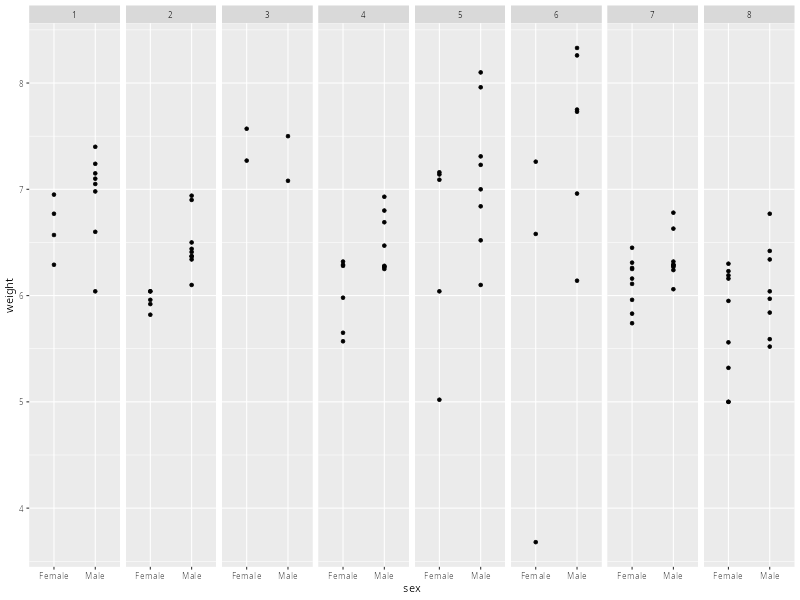

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

In [10]:
library(ggplot2)

litters.to.plot <- as.character(seq(1,8))                       # select litters to plot
ratpup.plot     <- ratpup[ratpup$litter %in% litters.to.plot, ] # subset rows by litter labels

ggplot(ratpup.plot, aes(x=sex, y=weight)) +
  geom_point() +
  geom_smooth() +
  facet_grid(~litter)

## Should `sex` be Fixed or Random?

In [11]:
lme.mod.0 <- lme(weight ~ treatment + sex + sex:treatment, random= ~       1|litter, data=ratpup, method='ML', control=lmeControl(opt='optim'))
lme.mod.1 <- lme(weight ~ treatment + sex + sex:treatment, random= ~ 1 + sex|litter, data=ratpup, method='ML', control=lmeControl(opt='optim')) 

anova(lme.mod.0,lme.mod.1)

          Model df      AIC      BIC    logLik   Test  L.Ratio p-value
lme.mod.0     1  8 425.9672 456.1636 -204.9836                        
lme.mod.1     2 10 425.2734 463.0189 -202.6367 1 vs 2 4.693801  0.0957

[^sextextbook-foot]: It is interesting to note that, in their description of this analysis, [West, Welch & Galecki (2022)](https://www.taylorfrancis.com/books/mono/10.1201/9781003181064/linear-mixed-models-brady-west-kathleen-welch-andrzej-galecki?context=ubx&refId=4dbda113-7f59-4ba9-a710-897ef536cfee) make the decision to fix `sex` to a constant across litters, under the belief that there is a universal effect of `sex` on weight that is not influenced by individual litters.